## Import Library

In [131]:
# ==========================================
# 4.1 Import Library
# ==========================================

import os
import re
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# agar hasil dapat direproduksi
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

plt.style.use("ggplot")

print("Library berhasil diimport.")

Library berhasil diimport.


## Load Dataset

In [132]:
# ==========================================
# 4.2 Load Dataset
# ==========================================

DATA_PATH = "/kaggle/input/datasets/puteriameliaazli/review-aplikasi-dana/ulasan_dana_cleaned.parquet"

df = pd.read_parquet(DATA_PATH)

In [133]:
df.head()

,id_ulasan,user,ulasan,rating,dukungan_ulasan,tanggal,versi_aplikasi
0,8c382ad2-2c81-436e-a18e-87be3fdcc662,Hermansyah Radin,ok,5,0,2026-01-22 09:14:57,unknown
1,47553db5-9026-4233-8bf7-8449e550da69,Zidni Cell,bagus,5,0,2026-01-22 09:11:52,unknown
2,9a1a84ba-1b7d-4010-a58d-1f373b280082,Akhi Sondi,mantulll pokok eh,5,0,2026-01-22 09:11:39,2.110.0
3,0460a39e-7580-44bf-8a79-8446fb2414eb,Yati Yati,mempermudah,5,0,2026-01-22 09:09:57,2.110.0
4,b461e228-9033-4bea-b835-322d0db38fc2,Joker 16,mantap,5,0,2026-01-22 09:09:34,2.111.0


In [134]:
print("Jumlah Data :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Data : 740000
Jumlah Kolom : 7


## Exploratory Data analysis

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740000 entries, 0 to 739999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_ulasan        740000 non-null  object        
 1   user             740000 non-null  object        
 2   ulasan           740000 non-null  object        
 3   rating           740000 non-null  int64         
 4   dukungan_ulasan  740000 non-null  int64         
 5   tanggal          740000 non-null  datetime64[ns]
 6   versi_aplikasi   740000 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(2), object(3)
memory usage: 35.3+ MB


In [136]:
df.describe()

,rating,dukungan_ulasan,tanggal
count,740000.000000,740000.000000,740000
mean,3.884432,0.742070,2024-12-22 01:27:51.385472
min,1.000000,0.000000,2023-12-31 07:53:41
25%,3.000000,0.000000,2024-06-07 20:12:09.750000128
50%,5.000000,0.000000,2024-12-05 02:35:46
75%,5.000000,0.000000,2025-07-02 21:14:04.500000
max,5.000000,8543.000000,2026-01-22 09:14:57
std,1.642963,38.177895,NaN


In [137]:
df.describe(include="object")

,id_ulasan,user,ulasan
count,740000,740000,740000
unique,740000,640597,417016
top,64ca9f4e-4034-40a5-9c3e-fae36b453171,Pengguna Google,mantap
freq,1,1149,29083


In [138]:
missing = df.isnull().sum()

missing

id_ulasan          0
user               0
ulasan             0
rating             0
dukungan_ulasan    0
tanggal            0
versi_aplikasi     0
dtype: int64

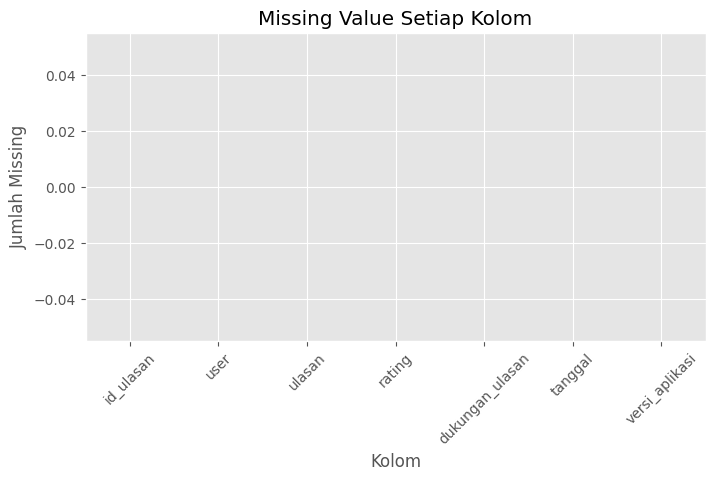

In [139]:
plt.figure(figsize=(8,4))

missing.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Missing Value Setiap Kolom")

plt.xlabel("Kolom")

plt.ylabel("Jumlah Missing")

plt.xticks(rotation=45)

plt.show()

In [140]:
# dupikat data

print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 0


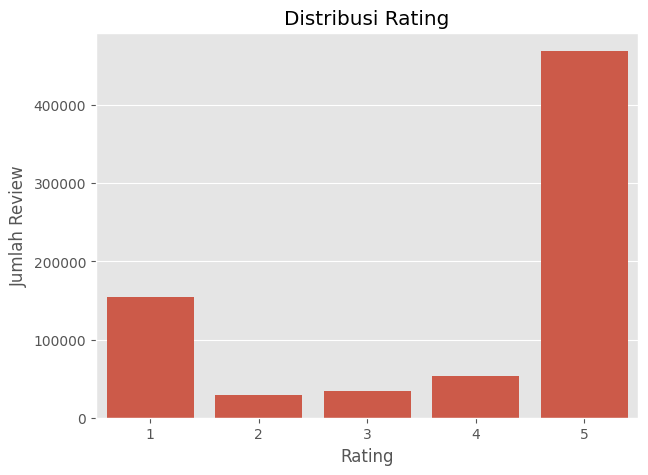

In [141]:
# distribusi rating

rating_counts = df["rating"].value_counts().sort_index()

rating_counts

plt.figure(figsize=(7,5))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Distribusi Rating")

plt.xlabel("Rating")

plt.ylabel("Jumlah Review")

plt.show()

In [142]:
# presentase rating

rating_percentage = (
    df["rating"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

rating_percentage.round(2)

rating
1    20.86
2     3.86
3     4.67
4     7.20
5    63.41
Name: proportion, dtype: float64

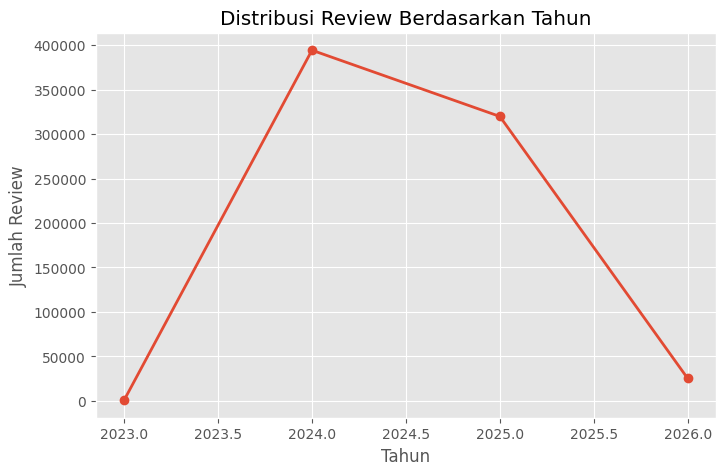

In [143]:
year_counts = (
    df["tanggal"]
    .dt.year
    .value_counts()
    .sort_index()
)

year_counts

plt.figure(figsize=(8,5))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    linewidth=2
)

plt.title("Distribusi Review Berdasarkan Tahun")

plt.xlabel("Tahun")

plt.ylabel("Jumlah Review")

plt.show()

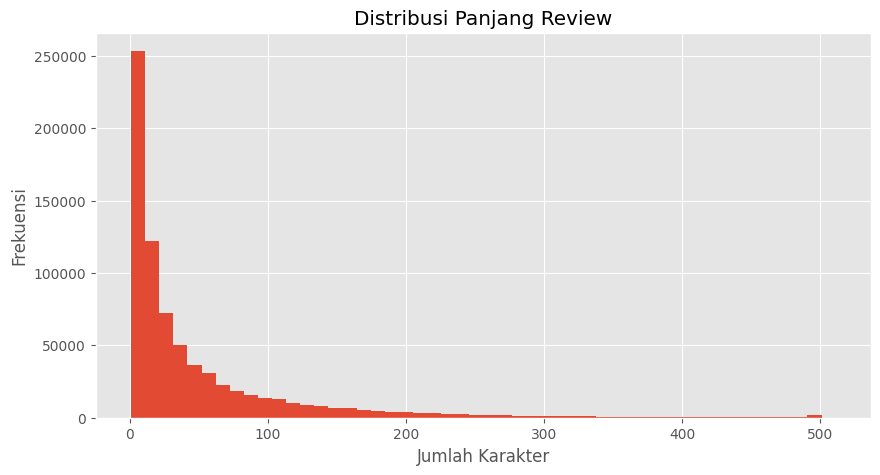

In [144]:
df["jumlah_karakter"] = df["ulasan"].str.len()

df["jumlah_karakter"].describe()

plt.figure(figsize=(10,5))

plt.hist(
    df["jumlah_karakter"],
    bins=50
)

plt.title("Distribusi Panjang Review")

plt.xlabel("Jumlah Karakter")

plt.ylabel("Frekuensi")

plt.show()

## Labeling

In [145]:
def label_sentimen(rating):

    if rating <= 2:
        return "Negatif"

    elif rating == 3:
        return "Netral"

    else:
        return "Positif"


df["label"] = df["rating"].apply(label_sentimen)

In [146]:
label_counts = df["label"].value_counts()

label_counts

label
Positif    522528
Negatif    182932
Netral      34540
Name: count, dtype: int64

In [147]:
label_percentage = (
    df["label"]
    .value_counts(normalize=True)
    *100
)

label_percentage.round(2)

label
Positif    70.61
Negatif    24.72
Netral      4.67
Name: proportion, dtype: float64

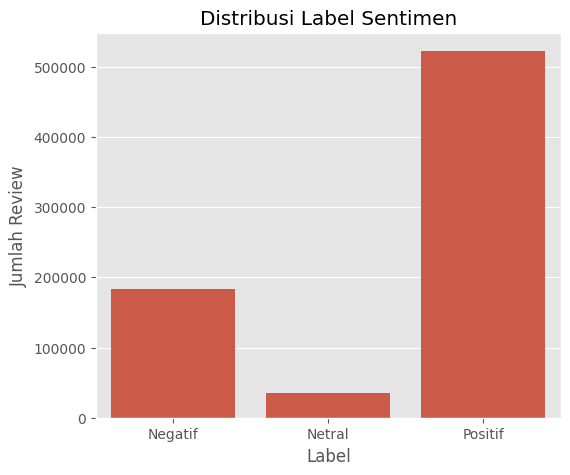

In [148]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="label",
    order=["Negatif","Netral","Positif"]
)

plt.title("Distribusi Label Sentimen")

plt.xlabel("Label")

plt.ylabel("Jumlah Review")

plt.show()

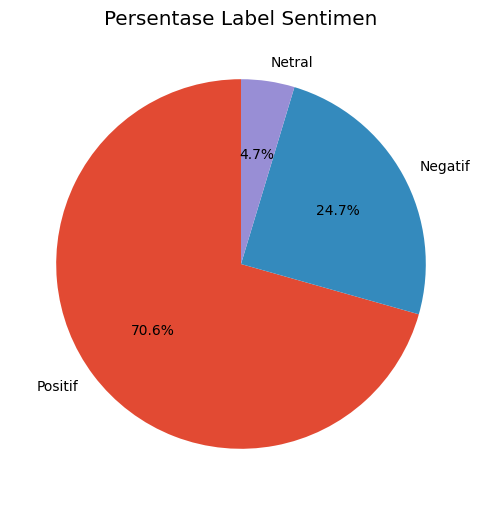

In [149]:
plt.figure(figsize=(6,6))

plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Persentase Label Sentimen")

plt.show()

## Preprocessing

In [150]:
def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # hapus url
    text = re.sub(r"http\S+|www\S+", "", text)

    # hapus mention
    text = re.sub(r"@\w+", "", text)

    # hapus hashtag
    text = re.sub(r"#", "", text)

    # hapus emoji
    text = text.encode("ascii","ignore").decode()

    # hapus angka
    text = re.sub(r"\d+", "", text)

    # hapus tanda baca
    text = re.sub(r"[^\w\s]", " ", text)

    # hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [151]:
df["clean_text"] = df["ulasan"].apply(clean_text)

In [152]:
df[
    [
        "ulasan",
        "clean_text"
    ]
].sample(10, random_state=42)

,ulasan,clean_text
631357,sangat bafuz,sangat bafuz
48754,sangat simpel teransaksi dan mudah di gunakan,sangat simpel teransaksi dan mudah di gunakan
478124,Wah ini bahaya sekali status transfer berhasil...,wah ini bahaya sekali status transfer berhasil...
506004,Sayah ga bisa masuk..harus prepesi wayah..trus...,sayah ga bisa masuk harus prepesi wayah trus h...
377823,Sangat membantu,sangat membantu
363605,Baru kemarin bisa ini setelah di up mlh gk bis...,baru kemarin bisa ini setelah di up mlh gk bis...
40206,sangat puas,sangat puas
187839,spektakuler,spektakuler
318440,Sangat bagus dan gampang caranya,sangat bagus dan gampang caranya
616428,mantap,mantap


In [153]:
df[
    [
        "clean_text",
        "label"
    ]
].isnull().sum()

clean_text    0
label         0
dtype: int64

In [154]:
df.to_parquet(
    "dana_preprocessed.parquet",
    index=False
)

## spilt dataset

In [155]:
# ==========================================
# 4.6 Split Dataset
# ==========================================

from sklearn.model_selection import train_test_split

In [156]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

In [157]:
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [158]:
print("Train :", train_df.shape)
print("Validation :", valid_df.shape)
print("Test :", test_df.shape)

Train : (592000, 10)
Validation : (74000, 10)
Test : (74000, 10)


In [159]:
print(train_df["label"].value_counts())

print()

print(valid_df["label"].value_counts())

print()

print(test_df["label"].value_counts())

label
Positif    418022
Negatif    146346
Netral      27632
Name: count, dtype: int64

label
Positif    52253
Negatif    18293
Netral      3454
Name: count, dtype: int64

label
Positif    52253
Negatif    18293
Netral      3454
Name: count, dtype: int64


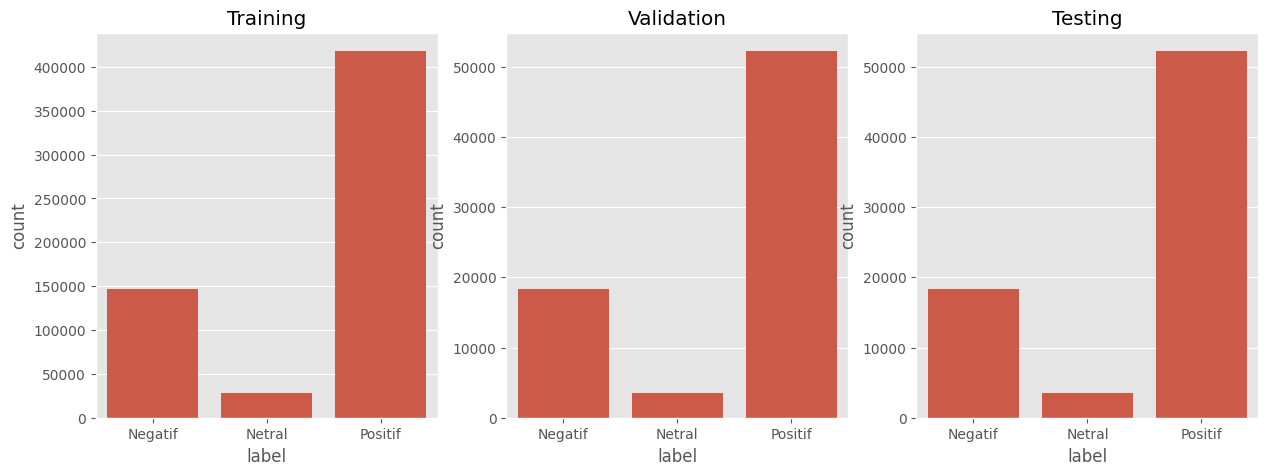

In [160]:
fig, ax = plt.subplots(1,3,figsize=(15,5))

sns.countplot(
    data=train_df,
    x="label",
    order=["Negatif","Netral","Positif"],
    ax=ax[0]
)

ax[0].set_title("Training")

sns.countplot(
    data=valid_df,
    x="label",
    order=["Negatif","Netral","Positif"],
    ax=ax[1]
)

ax[1].set_title("Validation")

sns.countplot(
    data=test_df,
    x="label",
    order=["Negatif","Netral","Positif"],
    ax=ax[2]
)

ax[2].set_title("Testing")

plt.show()

## Tokenisasi Indobert

In [161]:
from transformers import AutoTokenizer

In [162]:
tokenizer = AutoTokenizer.from_pretrained(
    "indobenchmark/indobert-base-p1"
)

In [163]:
token_lengths = train_df["clean_text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

In [164]:
token_lengths.describe()

count    592000.000000
mean          9.006465
std          12.911159
min           0.000000
25%           2.000000
50%           4.000000
75%          11.000000
max         198.000000
Name: clean_text, dtype: float64

In [165]:
print("95% :", np.percentile(token_lengths,95))
print("99% :", np.percentile(token_lengths,99))

95% : 35.0
99% : 65.0


## Encoding Label

In [166]:
# Mapping

label2id = {
    "Negatif": 0,
    "Netral": 1,
    "Positif": 2
}

id2label = {
    0: "Negatif",
    1: "Netral",
    2: "Positif"
}


# Encode

train_df["labels"] = train_df["label"].map(label2id)
valid_df["labels"] = valid_df["label"].map(label2id)
test_df["labels"] = test_df["label"].map(label2id)

In [167]:
print("Train:")
print(train_df["labels"].isna().sum())

print("Validation:")
print(valid_df["labels"].isna().sum())

print("Test:")
print(test_df["labels"].isna().sum())

Train:
0
Validation:
0
Test:
0


In [168]:
print(train_df[["label", "labels"]].head(10))

          label  labels
558420  Positif       2
170712  Negatif       0
168359  Positif       2
146535  Positif       2
164030  Positif       2
202594  Positif       2
338168  Negatif       0
171158  Positif       2
191643  Positif       2
157712  Positif       2


## Hugging Face Dataset

In [169]:
from datasets import Dataset

train_hf = Dataset.from_pandas(
    train_df[["clean_text", "labels"]],
    preserve_index=False
)

valid_hf = Dataset.from_pandas(
    valid_df[["clean_text", "labels"]],
    preserve_index=False
)

test_hf = Dataset.from_pandas(
    test_df[["clean_text", "labels"]],
    preserve_index=False
)

## Tokenisasi

In [170]:
MAX_LENGTH = 64

def tokenize_function(batch):
    return tokenizer(
        batch["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [171]:
train_tokenized = train_hf.map(
    tokenize_function,
    batched=True,
    batch_size=1000
)

valid_tokenized = valid_hf.map(
    tokenize_function,
    batched=True,
    batch_size=1000
)

test_tokenized = test_hf.map(
    tokenize_function,
    batched=True,
    batch_size=1000
)

Map:   0%|          | 0/592000 [00:00<?, ? examples/s]

Map:   0%|          | 0/74000 [00:00<?, ? examples/s]

Map:   0%|          | 0/74000 [00:00<?, ? examples/s]

## Load Medel Indobert

In [172]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "indobenchmark/indobert-base-p1"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [173]:
label2id = {
    "Negatif": 0,
    "Netral": 1,
    "Positif": 2
}

id2label = {
    0: "Negatif",
    1: "Netral",
    2: "Positif"
}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [174]:
print(model.classifier)

Linear(in_features=768, out_features=3, bias=True)


In [175]:
## Periksa GPU tersedia

import torch

print("CUDA tersedia :", torch.cuda.is_available())
print("Jumlah GPU    :", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i} :", torch.cuda.get_device_name(i))

CUDA tersedia : True
Jumlah GPU    : 2
GPU 0 : Tesla T4
GPU 1 : Tesla T4


In [176]:
print("Train :", len(train_tokenized))
print("Valid :", len(valid_tokenized))
print("Test  :", len(test_tokenized))

Train : 592000
Valid : 74000
Test  : 74000


## hitung hyperparameter

In [177]:
import math

BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 2
NUM_EPOCHS = 3

steps_per_epoch = math.ceil(
    len(train_tokenized) /
    (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
)

total_training_steps = steps_per_epoch * NUM_EPOCHS

warmup_steps = int(0.1 * total_training_steps)

print("Steps per epoch :", steps_per_epoch)
print("Total steps     :", total_training_steps)
print("Warmup steps    :", warmup_steps)

Steps per epoch : 18500
Total steps     : 55500
Warmup steps    : 5550


## TrainingArguments

In [178]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./hasil_indobert",

    # Training & validation
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",

    # Hyperparameter
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=3,

    # Regularization
    weight_decay=0.01,

    # Learning-rate scheduler
    lr_scheduler_type="linear",
    warmup_steps=5550,

    # GPU T4
    fp16=True,

    # Logging
    logging_strategy="steps",
    logging_steps=1000,

    # Best model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Checkpoint
    save_total_limit=2,

    # Reproducibility
    seed=42,
    data_seed=42,

    # Disable external logging
    report_to="none",

    # Data loading
    dataloader_num_workers=2,

    # Optimizer
    optim="adamw_torch_fused"
)

In [179]:
# compute_metric

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [180]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    compute_metrics=compute_metrics
)

In [181]:
print("===== TRAINING CONFIGURATION =====")

print("Train data      :", len(train_tokenized))
print("Validation data :", len(valid_tokenized))
print("Test data       :", len(test_tokenized))

print("Batch size      :", 16)
print("Gradient accum. :", 2)
print("Effective batch :", 32)

print("Epoch           :", 3)
print("Learning rate   :", 2e-5)
print("Max length      :", 64)

print("Steps/epoch     :", 18500)
print("Total steps     :", 55500)
print("Warmup steps    :", 5550)

print("FP16            :", True)

print("==================================")

===== TRAINING CONFIGURATION =====
Train data      : 592000
Validation data : 74000
Test data       : 74000
Batch size      : 16
Gradient accum. : 2
Effective batch : 32
Epoch           : 3
Learning rate   : 2e-05
Max length      : 64
Steps/epoch     : 18500
Total steps     : 55500
Warmup steps    : 5550
FP16            : True


In [182]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.456901,0.703706,0.883230,0.869488,0.883230,0.862545
2,1.363747,0.700043,0.885919,0.867493,0.885919,0.866230
3,1.296891,0.708625,0.884108,0.859944,0.884108,0.866196


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

## Evaluasi Model pada Test Set

In [183]:
# ==========================================
# 4.11 Evaluasi Model pada Test Set
# ==========================================

import numpy as np
import pandas as pd

# Evaluasi menggunakan test set
test_result = trainer.evaluate(
    eval_dataset=test_tokenized
)

print("===== HASIL EVALUASI TEST SET =====")

print(
    f"Test Loss  : {test_result['eval_loss']:.4f}"
)

print(
    f"Accuracy    : {test_result['eval_accuracy']:.4f}"
)

print(
    f"Precision   : {test_result['eval_precision']:.4f}"
)

print(
    f"Recall      : {test_result['eval_recall']:.4f}"
)

print(
    f"F1-Score    : {test_result['eval_f1']:.4f}"
)

print("===================================")

===== HASIL EVALUASI TEST SET =====
Test Loss  : 0.6980
Accuracy    : 0.8861
Precision   : 0.8664
Recall      : 0.8861
F1-Score    : 0.8663


In [184]:
print(
    f"Accuracy  : {test_result['eval_accuracy'] * 100:.2f}%"
)

print(
    f"Precision : {test_result['eval_precision'] * 100:.2f}%"
)

print(
    f"Recall    : {test_result['eval_recall'] * 100:.2f}%"
)

print(
    f"F1-Score  : {test_result['eval_f1'] * 100:.2f}%"
)

Accuracy  : 88.61%
Precision : 86.64%
Recall    : 88.61%
F1-Score  : 86.63%


## Prediksi pada Test Set

In [185]:
# ==========================================
# 4.12 Prediksi Test Set
# ==========================================

prediction_output = trainer.predict(
    test_tokenized
)

logits = prediction_output.predictions

y_true = prediction_output.label_ids

y_pred = np.argmax(
    logits,
    axis=-1
)

print("Jumlah data test       :", len(y_true))
print("Jumlah hasil prediksi  :", len(y_pred))

Jumlah data test       : 74000
Jumlah hasil prediksi  : 74000


## Probabilitas Prediksi

In [186]:
# ==========================================
# 4.13 Probabilitas Prediksi
# ==========================================

from scipy.special import softmax

probabilities = softmax(
    logits,
    axis=1
)

print("Shape probabilitas:", probabilities.shape)

Shape probabilitas: (74000, 3)


In [187]:
print(probabilities[0])

[0.66994303 0.21855429 0.11150272]


## Classification Report

In [188]:
# ==========================================
# 4.14 Classification Report
# ==========================================

from sklearn.metrics import classification_report

class_names = [
    "Negatif",
    "Netral",
    "Positif"
]

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    digits=4,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Negatif     0.7937    0.8650    0.8278     18293
      Netral     0.4286    0.0087    0.0170      3454
     Positif     0.9208    0.9515    0.9359     52253

    accuracy                         0.8861     74000
   macro avg     0.7144    0.6084    0.5936     74000
weighted avg     0.8664    0.8861    0.8663     74000



In [189]:
display(
    report_df.round(4)
)

,precision,recall,f1-score,support
Negatif,0.7937,0.8650,0.8278,18293.0000
Netral,0.4286,0.0087,0.0170,3454.0000
Positif,0.9208,0.9515,0.9359,52253.0000
accuracy,0.8861,0.8861,0.8861,0.8861
macro avg,0.7144,0.6084,0.5936,74000.0000
weighted avg,0.8664,0.8861,0.8663,74000.0000


## Confusion Matrix

In [190]:
# ==========================================
# 4.15 Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[15823    17  2453]
 [ 1599    30  1825]
 [ 2513    23 49717]]


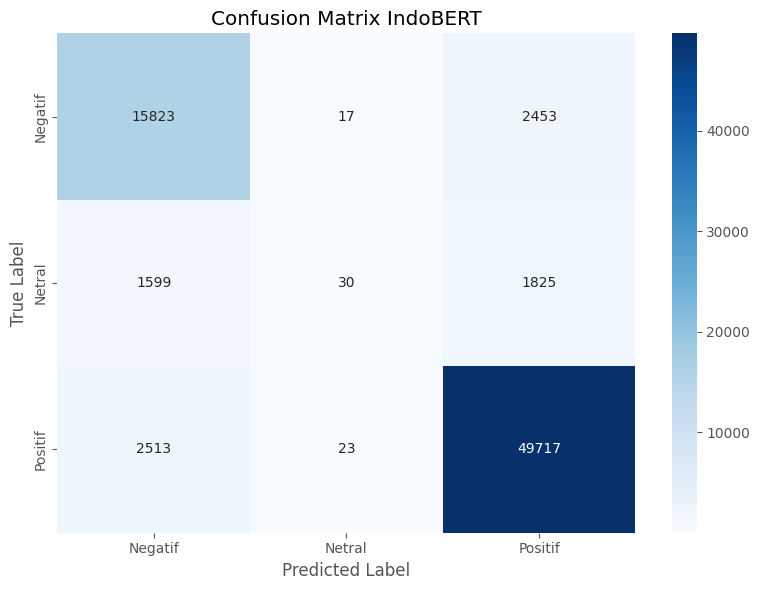

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix IndoBERT")

plt.tight_layout()
plt.show()

## Evaluasi Macro F1 dan Weighted F1

In [192]:
# ==========================================
# 4.16 Macro F1 dan Weighted F1
# ==========================================

macro_precision = report_dict["macro avg"]["precision"]
macro_recall = report_dict["macro avg"]["recall"]
macro_f1 = report_dict["macro avg"]["f1-score"]

weighted_precision = report_dict["weighted avg"]["precision"]
weighted_recall = report_dict["weighted avg"]["recall"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]

print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")

print()

print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")

Macro Precision   : 0.7144
Macro Recall      : 0.6084
Macro F1          : 0.5936

Weighted Precision : 0.8664
Weighted Recall    : 0.8861
Weighted F1       : 0.8663


## Tabel Ringkasan Evaluasi

In [193]:
# ==========================================
# 4.17 Tabel Ringkasan Evaluasi
# ==========================================

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],

    "Score": [
        test_result["eval_accuracy"],
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

evaluation_summary["Score (%)"] = (
    evaluation_summary["Score"] * 100
).round(2)

display(
    evaluation_summary
)

,Metric,Score,Score (%)
0,Accuracy,0.886081,88.61
1,Macro Precision,0.714357,71.44
2,Macro Recall,0.608376,60.84
3,Macro F1,0.593572,59.36
4,Weighted Precision,0.866392,86.64
5,Weighted Recall,0.886081,88.61
6,Weighted F1,0.866271,86.63


,precision,recall,f1-score
Negatif,0.7937,0.8650,0.8278
Netral,0.4286,0.0087,0.0170
Positif,0.9208,0.9515,0.9359


<Figure size 900x600 with 0 Axes>

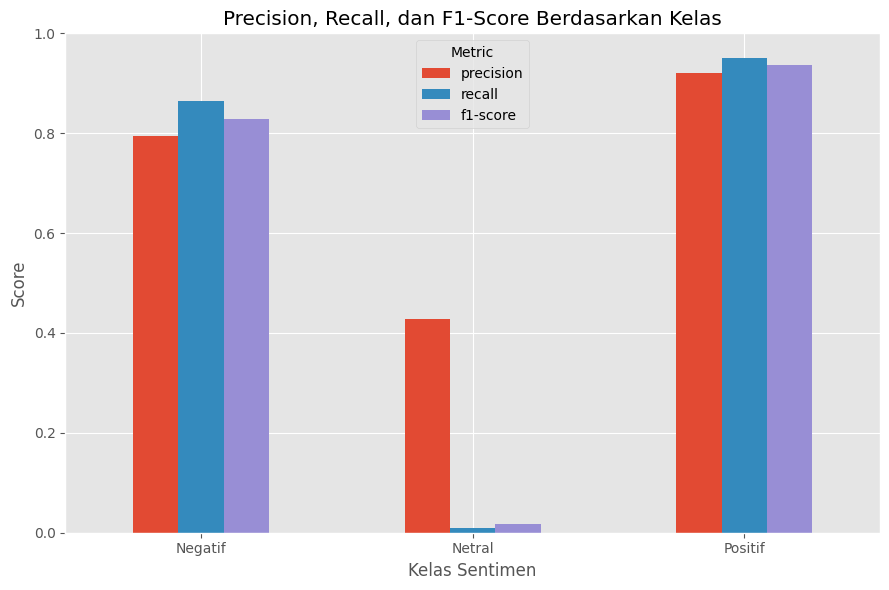

In [194]:
# ==========================================
# 4.18 Performa Tiap Kelas
# ==========================================

class_metrics = report_df.loc[
    ["Negatif", "Netral", "Positif"],
    ["precision", "recall", "f1-score"]
]

display(
    class_metrics.round(4)
)

plt.figure(figsize=(9, 6))

class_metrics.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Precision, Recall, dan F1-Score Berdasarkan Kelas"
)

plt.xlabel("Kelas Sentimen")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metric"
)

plt.tight_layout()

plt.show()

In [195]:
# ==========================================
# 4.19 Analisis Kesalahan Klasifikasi
# ==========================================

error_analysis = test_df[
    ["clean_text", "label", "rating", "tanggal", "versi_aplikasi"]
].copy()

error_analysis["true_label"] = y_true

error_analysis["predicted_label"] = y_pred

error_analysis["confidence"] = probabilities.max(
    axis=1
)

error_analysis["true_label"] = (
    error_analysis["true_label"]
    .map(id2label)
)

error_analysis["predicted_label"] = (
    error_analysis["predicted_label"]
    .map(id2label)
)

In [196]:
misclassified = error_analysis[
    error_analysis["true_label"]
    != error_analysis["predicted_label"]
].copy()

print(
    "Jumlah salah klasifikasi:",
    len(misclassified)
)

print(
    f"Persentase salah klasifikasi: "
    f"{len(misclassified) / len(error_analysis) * 100:.2f}%"
)

Jumlah salah klasifikasi: 8430
Persentase salah klasifikasi: 11.39%


In [197]:
misclassified = error_analysis[
    error_analysis["true_label"]
    != error_analysis["predicted_label"]
].copy()

print(
    "Jumlah salah klasifikasi:",
    len(misclassified)
)

print(
    f"Persentase salah klasifikasi: "
    f"{len(misclassified) / len(error_analysis) * 100:.2f}%"
)

Jumlah salah klasifikasi: 8430
Persentase salah klasifikasi: 11.39%


## Visualisasi Hasil

In [198]:
# ==========================================
# 5.1 Training History
# ==========================================

history_df = pd.DataFrame(
    trainer.state.log_history
)

display(history_df.head())

print(
    "Kolom:",
    history_df.columns.tolist()
)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.869178,8.190143,0.000004,0.108108,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.465039,8.160820,0.000007,0.216216,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.447420,12.221914,0.000011,0.324324,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.462105,9.178670,0.000014,0.432432,4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.471307,5.961036,0.000018,0.540541,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Kolom: ['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


In [199]:
train_history = history_df[
    history_df["loss"].notna()
].copy()

eval_history = history_df[
    history_df["eval_loss"].notna()
].copy()

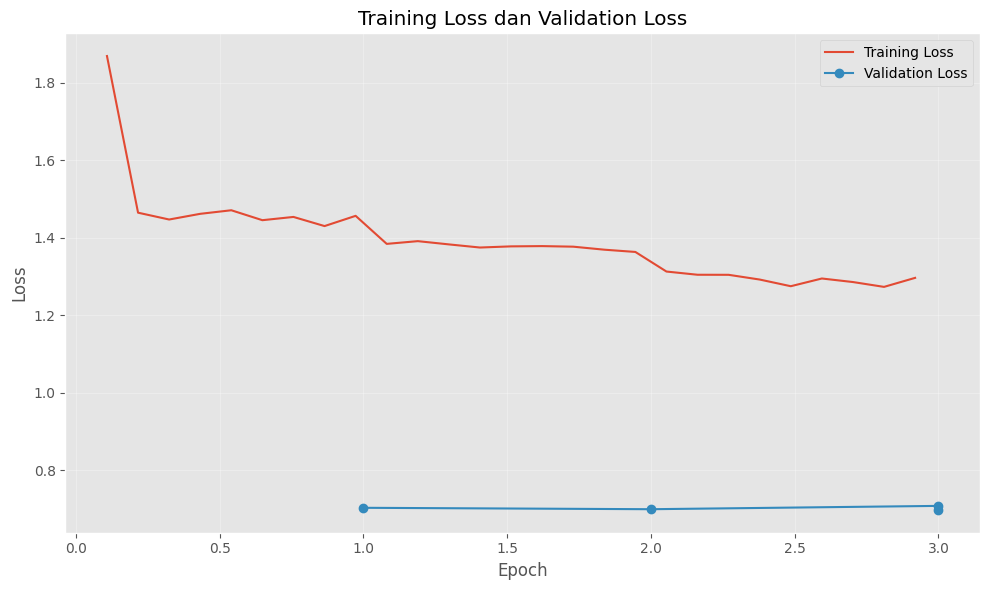

In [200]:
# ==========================================
# 5.2 Training vs Validation Loss
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    train_history["epoch"],
    train_history["loss"],
    label="Training Loss"
)

plt.plot(
    eval_history["epoch"],
    eval_history["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training Loss dan Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

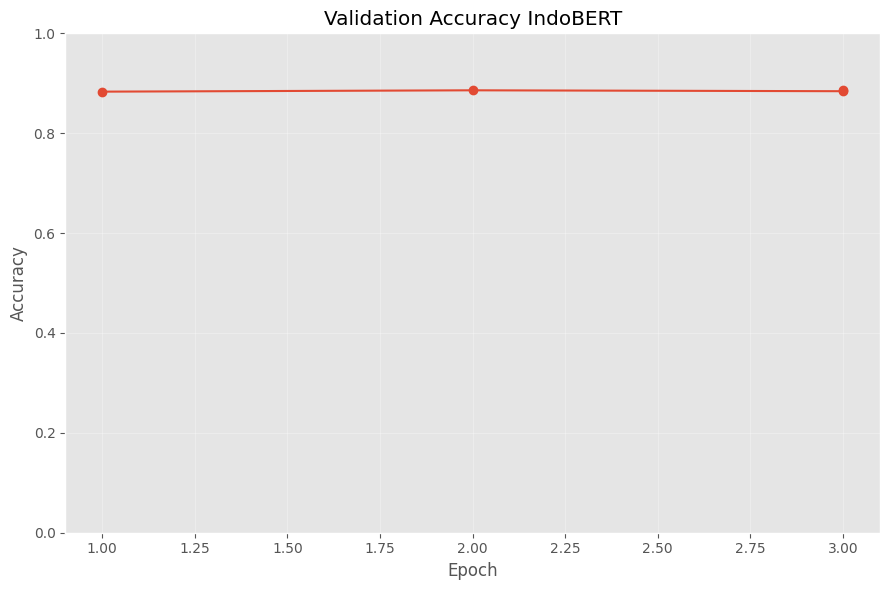

In [201]:
# ==========================================
# 5.3 Validation Accuracy
# ==========================================

plt.figure(figsize=(9, 6))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_accuracy"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Validation Accuracy IndoBERT"
)

plt.ylim(0, 1)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

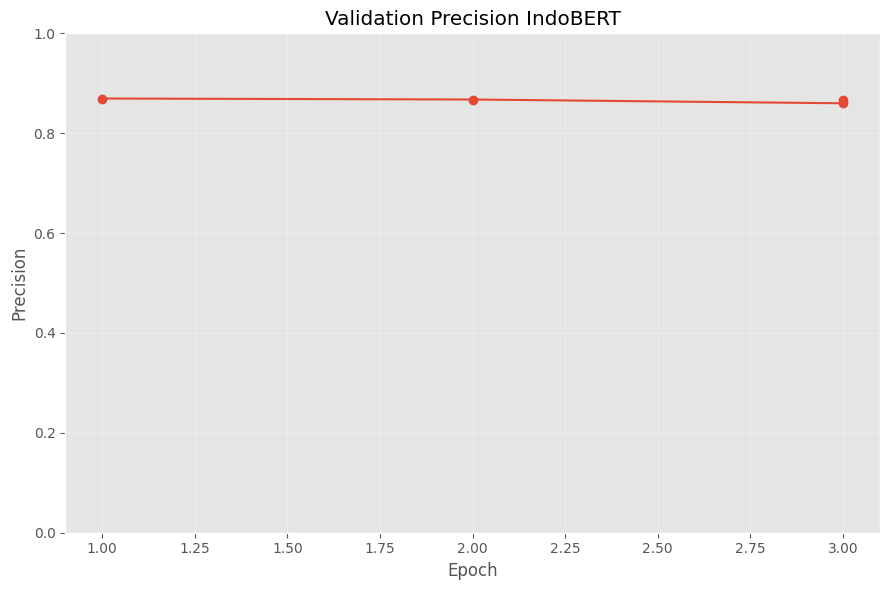

In [202]:
# ==========================================
# 5.4 Validation Precision
# ==========================================

plt.figure(figsize=(9, 6))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_precision"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.title(
    "Validation Precision IndoBERT"
)

plt.ylim(0, 1)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

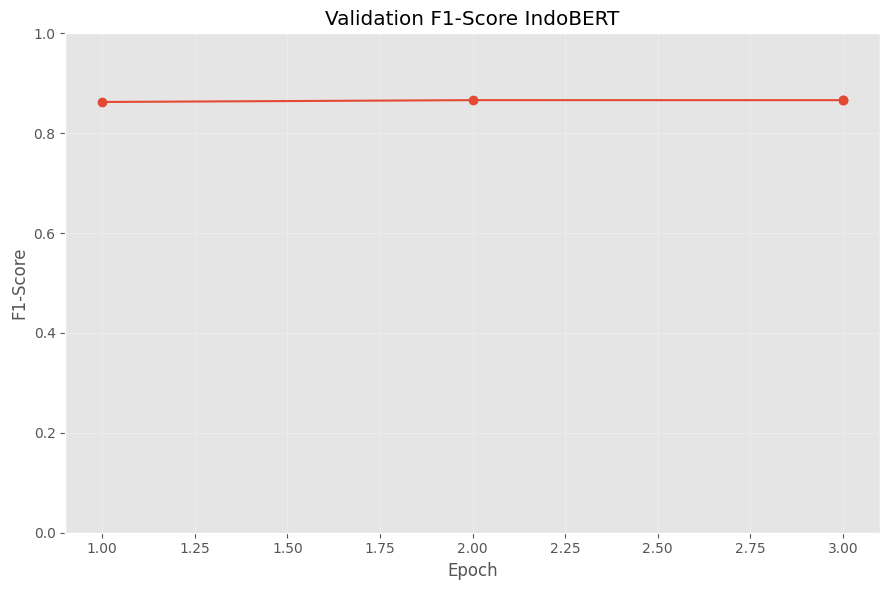

In [203]:
# ==========================================
# 5.6 Validation F1
# ==========================================

plt.figure(figsize=(9, 6))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_f1"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("F1-Score")

plt.title(
    "Validation F1-Score IndoBERT"
)

plt.ylim(0, 1)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

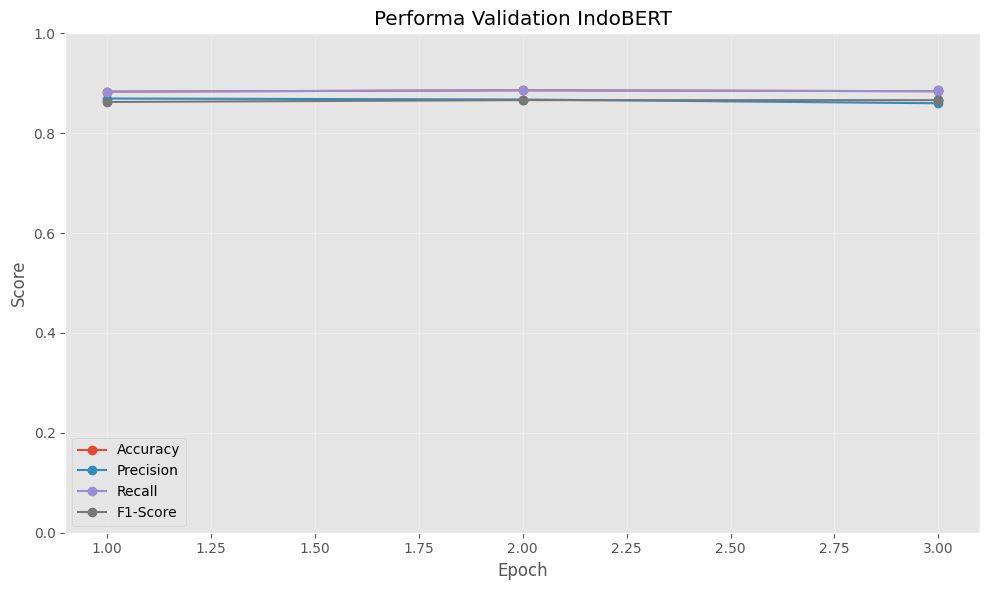

In [204]:
# ==========================================
# 5.7 Validation Metrics
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    eval_history["epoch"],
    eval_history["eval_precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    eval_history["epoch"],
    eval_history["eval_recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    eval_history["epoch"],
    eval_history["eval_f1"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Epoch")

plt.ylabel("Score")

plt.title(
    "Performa Validation IndoBERT"
)

plt.ylim(0, 1)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

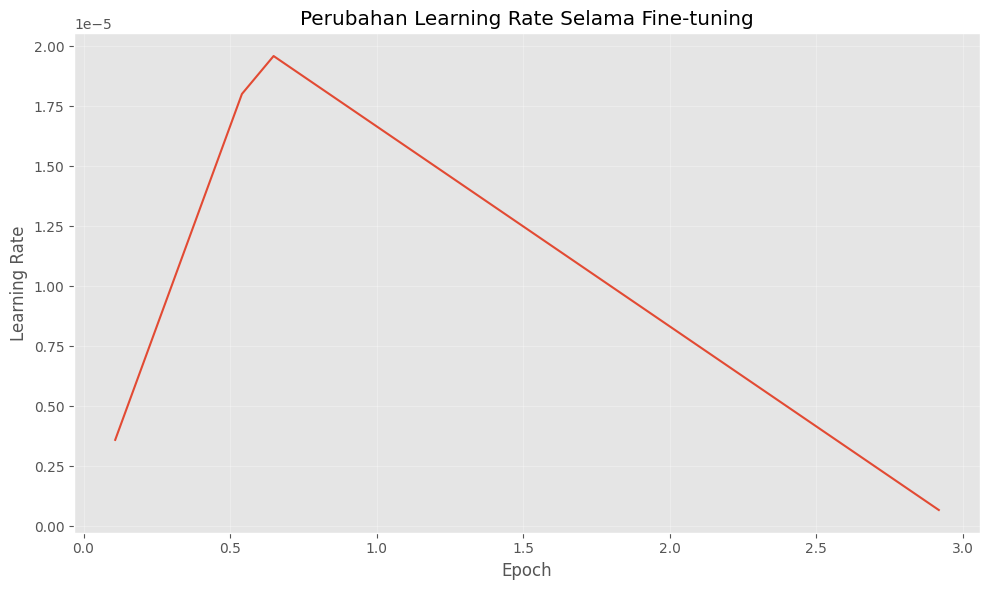

In [205]:
# ==========================================
# 5.8 Learning Rate
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    train_history["epoch"],
    train_history["learning_rate"]
)

plt.xlabel("Epoch")

plt.ylabel("Learning Rate")

plt.title(
    "Perubahan Learning Rate Selama Fine-tuning"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Epoch Terbaik

In [206]:
metric_for_best_model="f1"

In [207]:
# ==========================================
# 5.9 Best Epoch
# ==========================================

best_idx = eval_history[
    "eval_f1"
].idxmax()

best_epoch = eval_history.loc[
    best_idx
]

print(
    f"Best Epoch      : {best_epoch['epoch']}"
)

print(
    f"Validation Loss : {best_epoch['eval_loss']:.4f}"
)

print(
    f"Validation Acc  : {best_epoch['eval_accuracy']:.4f}"
)

print(
    f"Validation F1   : {best_epoch['eval_f1']:.4f}"
)

Best Epoch      : 3.0
Validation Loss : 0.6980
Validation Acc  : 0.8861
Validation F1   : 0.8663


Negatif    19935
Netral        70
Positif    53995
Name: count, dtype: int64

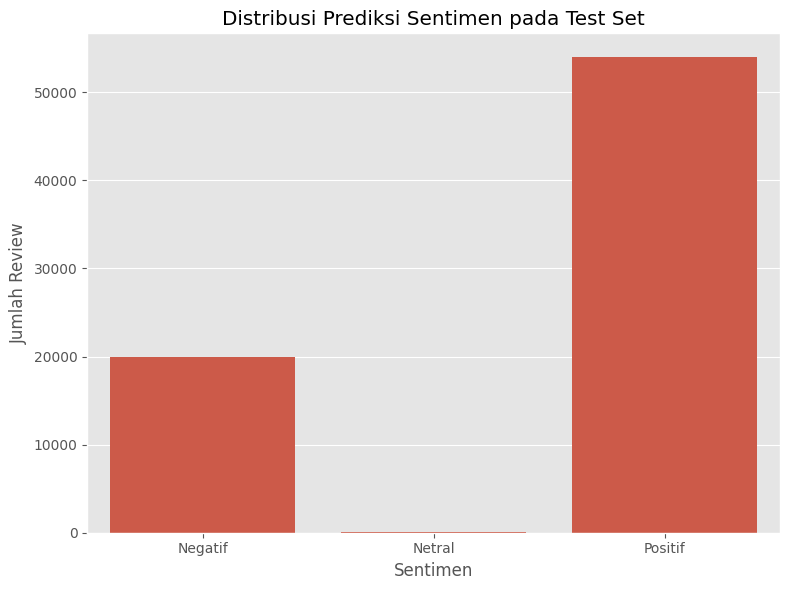

In [208]:
# ==========================================
# 5.10 Distribusi Prediksi
# ==========================================

predicted_labels = pd.Series(
    y_pred
).map(id2label)

predicted_counts = (
    predicted_labels
    .value_counts()
    .reindex(
        ["Negatif", "Netral", "Positif"],
        fill_value=0
    )
)

display(
    predicted_counts
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=predicted_counts.index,
    y=predicted_counts.values
)

plt.xlabel("Sentimen")

plt.ylabel("Jumlah Review")

plt.title(
    "Distribusi Prediksi Sentimen pada Test Set"
)

plt.tight_layout()

plt.show()

,Actual,Predicted
Negatif,18293,19935
Netral,3454,70
Positif,52253,53995


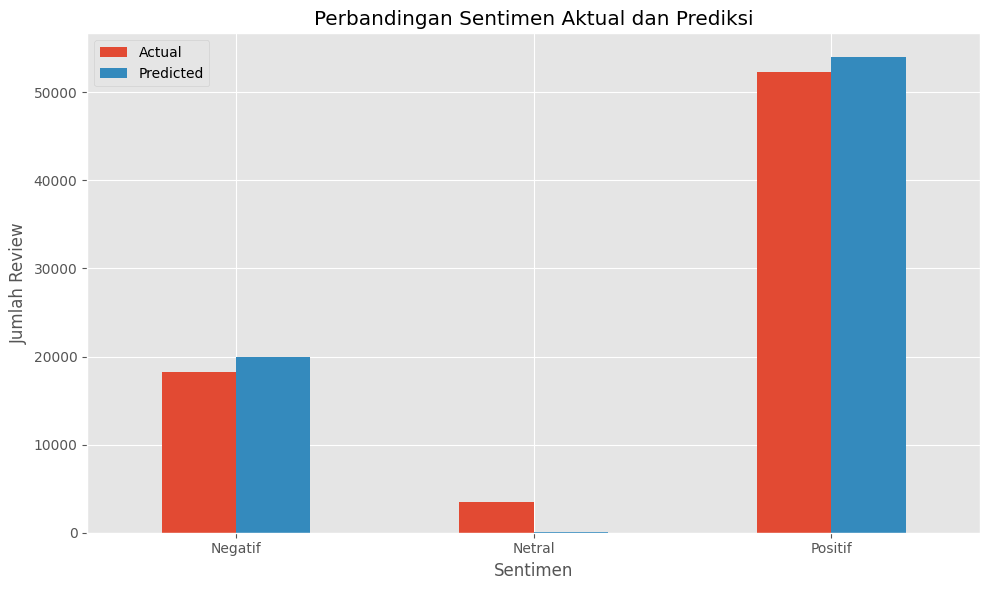

In [209]:
# ==========================================
# 5.11 Actual vs Predicted
# ==========================================

actual_counts = (
    pd.Series(y_true)
    .map(id2label)
    .value_counts()
    .reindex(
        ["Negatif", "Netral", "Positif"],
        fill_value=0
    )
)

comparison_df = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
})

display(comparison_df)

comparison_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Sentimen")

plt.ylabel("Jumlah Review")

plt.title(
    "Perbandingan Sentimen Aktual dan Prediksi"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [210]:
# ==========================================
# 5.12 Sentimen Berdasarkan Rating
# ==========================================

test_analysis = test_df.copy()

test_analysis["true_label"] = y_true

test_analysis["predicted_label"] = y_pred

test_analysis["true_label"] = (
    test_analysis["true_label"]
    .map(id2label)
)

test_analysis["predicted_label"] = (
    test_analysis["predicted_label"]
    .map(id2label)
)

In [211]:
rating_sentiment = pd.crosstab(
    test_analysis["rating"],
    test_analysis["predicted_label"]
)

display(
    rating_sentiment
)

predicted_label,Negatif,Netral,Positif
rating,,,
1,13788,6,1668
2,2035,11,785
3,1599,30,1825
4,693,16,4594
5,1820,7,45123


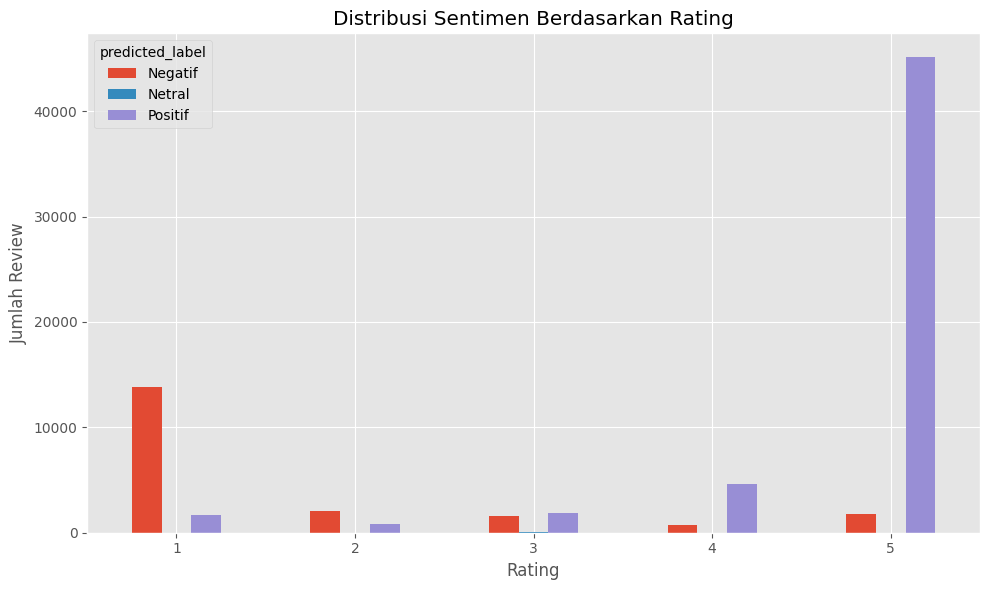

In [212]:
rating_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Rating")

plt.ylabel("Jumlah Review")

plt.title(
    "Distribusi Sentimen Berdasarkan Rating"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Analisis Proporsi Sentimen Berdasarkan Rating

predicted_label,Negatif,Netral,Positif
rating,,,
1,89.17,0.04,10.79
2,71.88,0.39,27.73
3,46.29,0.87,52.84
4,13.07,0.30,86.63
5,3.88,0.01,96.11


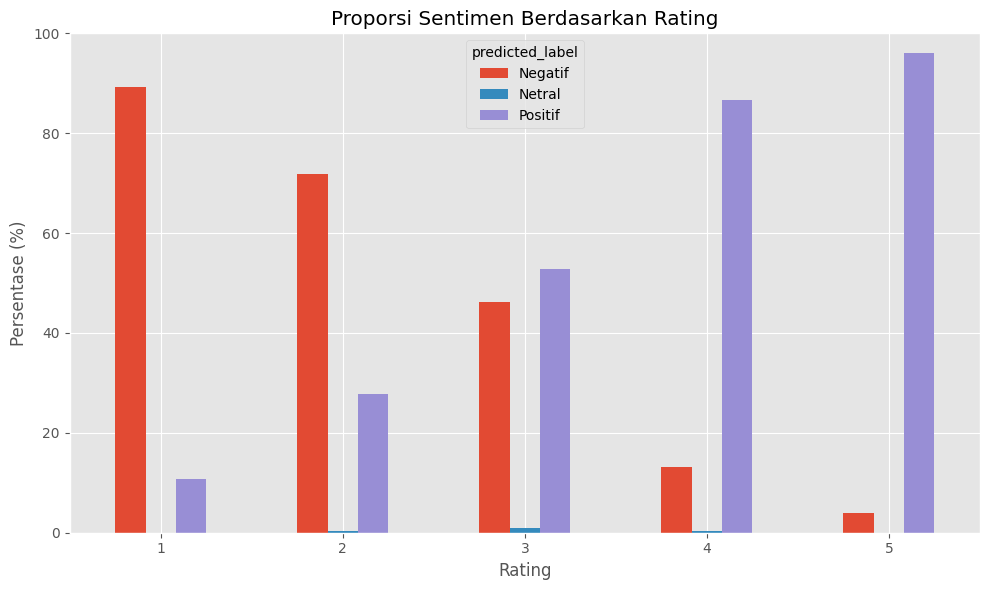

In [213]:
rating_sentiment_pct = (
    rating_sentiment
    .div(
        rating_sentiment.sum(axis=1),
        axis=0
    )
    * 100
)

display(
    rating_sentiment_pct.round(2)
)

rating_sentiment_pct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Rating")

plt.ylabel("Persentase (%)")

plt.title(
    "Proporsi Sentimen Berdasarkan Rating"
)

plt.xticks(rotation=0)

plt.ylim(0, 100)

plt.tight_layout()

plt.show()

In [214]:
# ==========================================
# 5.16 Stopword untuk Analisis Kata
# ==========================================

stopwords_id = {
    "yang", "dan", "di", "ke", "dari",
    "ini", "itu", "untuk", "dengan",
    "pada", "ada", "saya", "aku",
    "nya", "jadi", "karena", "atau",
    "juga", "tidak", "bisa", "sudah",
    "akan", "dalam", "sebagai",
    "lebih", "sangat", "sih", "ya",
    "aja", "nya", "lah", "pun"
}

In [215]:
from collections import Counter

def get_top_words(
    texts,
    n=20
):

    counter = Counter()

    for text in texts:

        words = str(text).lower().split()

        words = [
            word
            for word in words
            if word not in stopwords_id
            and len(word) > 2
        ]

        counter.update(words)

    return counter.most_common(n)

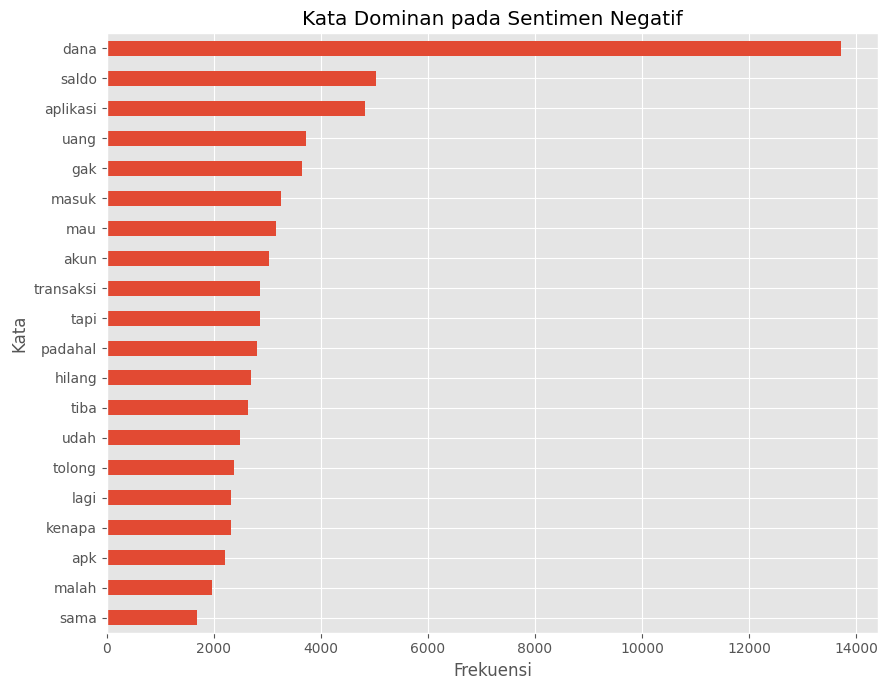

In [216]:
negative_texts = test_analysis.loc[
    test_analysis["predicted_label"] == "Negatif",
    "clean_text"
]

negative_words = get_top_words(
    negative_texts,
    n=20
)

negative_words

negative_words_df = pd.DataFrame(
    negative_words,
    columns=["Kata", "Frekuensi"]
)

negative_words_df.sort_values(
    "Frekuensi"
).plot(
    kind="barh",
    x="Kata",
    y="Frekuensi",
    figsize=(9, 7),
    legend=False
)

plt.xlabel("Frekuensi")

plt.ylabel("Kata")

plt.title(
    "Kata Dominan pada Sentimen Negatif"
)

plt.tight_layout()

plt.show()

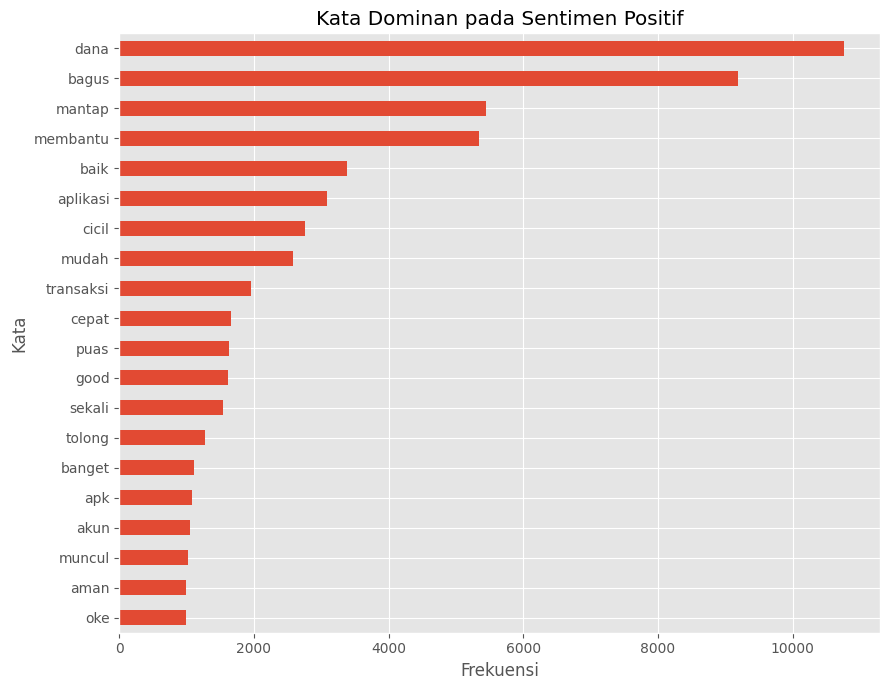

In [217]:
positive_texts = test_analysis.loc[
    test_analysis["predicted_label"] == "Positif",
    "clean_text"
]

positive_words = get_top_words(
    positive_texts,
    n=20
)

positive_words_df = pd.DataFrame(
    positive_words,
    columns=["Kata", "Frekuensi"]
)

positive_words_df.sort_values(
    "Frekuensi"
).plot(
    kind="barh",
    x="Kata",
    y="Frekuensi",
    figsize=(9, 7),
    legend=False
)

plt.xlabel("Frekuensi")

plt.ylabel("Kata")

plt.title(
    "Kata Dominan pada Sentimen Positif"
)

plt.tight_layout()

plt.show()

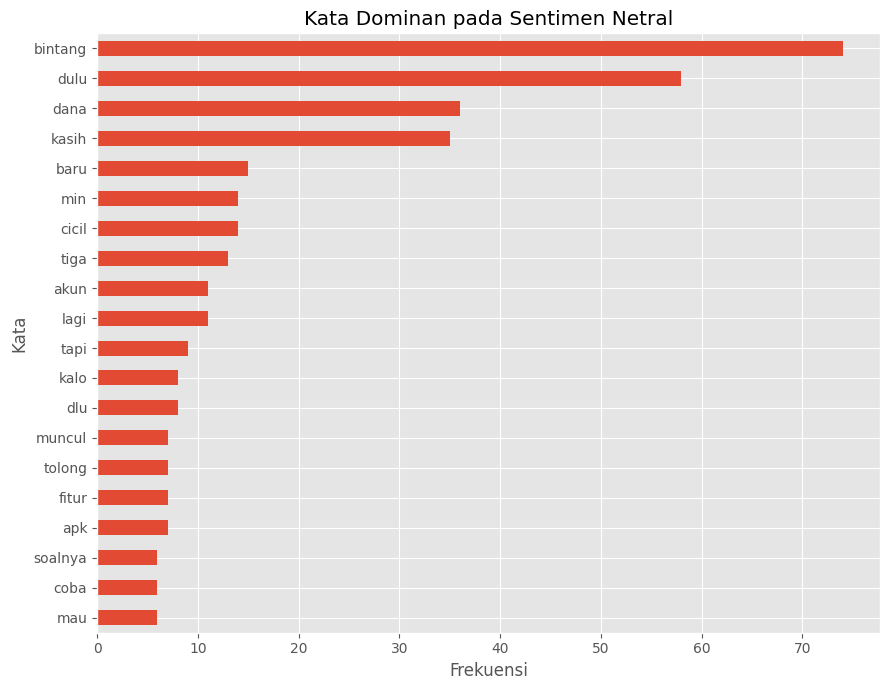

In [218]:
neutral_texts = test_analysis.loc[
    test_analysis["predicted_label"] == "Netral",
    "clean_text"
]

neutral_words = get_top_words(
    neutral_texts,
    n=20
)

neutral_words_df = pd.DataFrame(
    neutral_words,
    columns=["Kata", "Frekuensi"]
)

neutral_words_df.sort_values(
    "Frekuensi"
).plot(
    kind="barh",
    x="Kata",
    y="Frekuensi",
    figsize=(9, 7),
    legend=False
)

plt.xlabel("Frekuensi")

plt.ylabel("Kata")

plt.title(
    "Kata Dominan pada Sentimen Netral"
)

plt.tight_layout()

plt.show()

In [219]:
error_pairs = pd.crosstab(
    misclassified["true_label"],
    misclassified["predicted_label"]
)

display(error_pairs)

error_pairs = pd.crosstab(
    misclassified["true_label"],
    misclassified["predicted_label"]
)

display(error_pairs)

predicted_label,Negatif,Netral,Positif
true_label,,,
Negatif,0,17,2453
Netral,1599,0,1825
Positif,2513,23,0


predicted_label,Negatif,Netral,Positif
true_label,,,
Negatif,0,17,2453
Netral,1599,0,1825
Positif,2513,23,0


## Simpan Hasil

In [220]:
# ==========================================
# 5.21 Simpan Hasil
# ==========================================

evaluation_summary.to_csv(
    "evaluation_summary.csv",
    index=False
)

report_df.to_csv(
    "classification_report.csv"
)

pd.DataFrame(
    cm,
    index=[
        "Actual_Negatif",
        "Actual_Netral",
        "Actual_Positif"
    ],
    columns=[
        "Pred_Negatif",
        "Pred_Netral",
        "Pred_Positif"
    ]
).to_csv(
    "confusion_matrix.csv"
)

history_df.to_csv(
    "training_history.csv",
    index=False
)

misclassified.to_csv(
    "misclassified_reviews.csv",
    index=False
)

print("Seluruh hasil berhasil disimpan.")

Seluruh hasil berhasil disimpan.


In [221]:
# ==========================================
# 5.22 Simpan Model
# ==========================================

MODEL_OUTPUT = "/kaggle/working/model_indobert_dana"

trainer.save_model(
    MODEL_OUTPUT
)

tokenizer.save_pretrained(
    MODEL_OUTPUT
)

print(
    "Model berhasil disimpan di:",
    MODEL_OUTPUT
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan di: /kaggle/working/model_indobert_dana


In [222]:
import shutil

zip_path = shutil.make_archive(
    "/kaggle/working/indobert_dana",
    "zip",
    MODEL_OUTPUT
)

print(zip_path)

/kaggle/working/indobert_dana.zip


In [223]:
from IPython.display import FileLink

FileLink(
    "/kaggle/working/indobert_dana.zip"
)

/kaggle/working/indobert_dana.zip

In [224]:
# ============================================================
# INDOBERT SENTIMENT ANALYSIS — ULASAN APLIKASI DANA
# ============================================================

# BAB 4.1 — Persiapan Lingkungan
#     - Import library
#     - Random seed
#     - Cek GPU

# BAB 4.2 — Load Dataset
#     - Load file Parquet
#     - Melihat struktur dataset
#     - Informasi dataset

# BAB 4.3 — Exploratory Data Analysis
#     - Missing value
#     - Duplikasi
#     - Distribusi rating
#     - Distribusi tahun
#     - Distribusi versi aplikasi
#     - Panjang ulasan

# BAB 4.4 — Pelabelan Sentimen
#     - Rating 1–2 → Negatif
#     - Rating 3   → Netral
#     - Rating 4–5 → Positif
#     - Encoding label

# BAB 4.5 — Preprocessing Teks
#     - Menangani teks kosong
#     - Pembersihan minimal
#     - Menyiapkan clean_text

# BAB 4.6 — Pembagian Dataset
#     - Train      : 80%
#     - Validation : 10%
#     - Test       : 10%
#     - Stratified split

# BAB 4.7 — Analisis Panjang Token
#     - Load tokenizer IndoBERT
#     - Menghitung panjang token
#     - Percentile 95%
#     - Percentile 99%
#     - Menentukan MAX_LENGTH

# BAB 4.8 — Hugging Face Dataset
#     - Pandas → Hugging Face Dataset
#     - Encoding label
#     - Tokenisasi
#     - Batched tokenization

# BAB 4.9 — Validasi Dataset
#     - Validasi jumlah data
#     - Validasi label
#     - Set format PyTorch
#     - Cek input_ids
#     - Cek attention_mask

# BAB 4.10 — Fine-tuning IndoBERT
#     - Load IndoBERT
#     - Menentukan hyperparameter
#     - TrainingArguments
#     - compute_metrics
#     - Trainer
#     - Fine-tuning

# BAB 4.11 — Evaluasi Model
#     - Evaluasi test set
#     - Prediksi
#     - Accuracy
#     - Precision
#     - Recall
#     - F1-score
#     - Classification report
#     - Confusion matrix

# BAB 4.12 — Visualisasi Training
#     - Training loss
#     - Validation loss
#     - Validation accuracy
#     - Validation precision
#     - Validation recall
#     - Validation F1
#     - Learning rate

# BAB 4.13 — Analisis Sentimen
#     - Distribusi prediksi
#     - Sentimen berdasarkan rating
#     - Sentimen berdasarkan tahun
#     - Sentimen berdasarkan versi aplikasi
#     - Kata dominan setiap sentimen

# BAB 4.14 — Analisis Kesalahan
#     - Misclassification
#     - Confidence
#     - High-confidence errors
#     - Analisis label noise

# BAB 4.15 — Penyimpanan Model
#     - Save model
#     - Save tokenizer
#     - Simpan hasil evaluasi
#     - ZIP model
#     - Download model